### Parte IV: Análisis Exploratorio de Datos (EDA) y Visualización
##### En esta cuarta parte del proyecto, aplicaremos técnicas avanzadas de análisis exploratorio de datos (EDA) y visualización para comprender mejor el conjunto de datos de ventas de la tienda de retail. Utilizaremos Python, Pandas y Matplotlib para explorar y visualizar los datos, identificar patrones y tendencias, y preparar los datos para un análisis más profundo.

### 1 .- Continuar desde la Parte III
##### - Asegúrate de tener el repositorio de GitHub clonado localmente y el dataset ya limpiado y preparado desde la Parte III.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#--Carga el archivo CSV en un DataFrame de Pandas.

df = pd.read_csv('data/retail_ferreteria.csv')
#print("df",df)
print(df.head(10))
    # Muestra las últimas 5 filas del DataFrame.
print(df.tail())    
    # Utiliza el método info() para obtener información general sobre el DataFrame, incluyendo el número de entradas, nombres de las columnas, tipos de datos y memoria utilizada.
print(df.info())
    # Genera estadísticas descriptivas del DataFrame utilizando el método describe().
print(df.describe())
    # Inspección de los Datos
print(df.dtypes)


#1.- Transformación de Datos
# --Crea nuevas columnas: Basándonos en los datos existentes, crea nuevas columnas que sean útiles para el análisis. Por ejemplo, calcula el ingreso total por venta y normaliza las ventas.
    # se crea columna de ingreso total por venta de articulos.
df['ingreso_total'] = df['cantidad'] * df['precio_unitario']

# --Clasifica los datos: Crea una columna que clasifique las ventas en categorías significativas (e.g., ‘Alta’, ‘Media’, ‘Baja’).
    # se utiliza la columna de ingreso_total para clasificar las ventas de cada articulo con las categoria ‘Alta’, ‘Media’, ‘Baja’
df['Clasificación'] = df['ingreso_total'].apply(lambda x: 'Alta' if x > 50000 else 'Media' if x > 15000 else 'Baja')
#print("df : ",df)
#2.- Agrupación y Agregación
# Agrupación por múltiples columnas: Realiza agrupaciones por categorías como producto y tienda, producto y mes, etc.
    # agrupamos para obtener productos vendidos en cada sucursal
group_x_sucpro = df.groupby(['sucursal', 'producto'])
# Suma y promedio de ventas por producto y mes
ventas_por_producto_y_mes = group_x_sucpro['total_venta'].agg(['sum', 'mean'])
    
print("ventas_por_producto_y_mes",ventas_por_producto_y_mes)
# Aplicar funciones de agregación: Utiliza funciones como sum, mean, count, min, max, std, y var para obtener estadísticas descriptivas de cada grupo.

    # Suma de ventas por sucursal
ventas_sucursal = df.groupby(['sucursal', 'producto'])['total_venta'].sum()
print("ventas_sucursal : \n",ventas_sucursal)


    # Promedio de ventas por sucursal
promedio_ventas_sucursal = df.groupby(['sucursal', 'producto'])['total_venta'].mean()
print("promedio_ventas_sucursal : \n",promedio_ventas_sucursal)

    # Número de ventas por sucursal
conteo_ventas_sucursal = df.groupby(['sucursal', 'producto'])['total_venta'].count()
print("conteo_ventas_sucursal : \n",conteo_ventas_sucursal)

    # Ventas mínimas y máximas por sucursal
ventas_minimas_por_sucursal = df.groupby(['sucursal', 'producto'])['total_venta'].min()
ventas_maximas_por_sucursal = df.groupby(['sucursal', 'producto'])['total_venta'].max()
print("ventas_minimas_por_sucursal : \n",ventas_minimas_por_sucursal)
print("ventas_maximas_por_sucursal \n",ventas_maximas_por_sucursal)

# Desviación estándar de las ventas por sucursal
desviacion_estandar_ventas = df.groupby(['sucursal', 'producto'])['total_venta'].std()
print(desviacion_estandar_ventas)

# Varianza de las ventas por sucursal
varianza_ventas = df.groupby(['sucursal', 'producto'])['total_venta'].var().round(2)

print(varianza_ventas)

#3.- Análisis Personalizado con apply
# --Función personalizada: Aplica funciones personalizadas para realizar análisis específicos que no se pueden lograr con las funciones de agregación estándar.
    # se clasifica el medio de pago si es en efectivo o con alguna tarjeta o atraves de la web
df['Clasificación_forma_compra'] = df['medio_pago'].apply(lambda x: 'efectivo' if x == "efectivo" else 'tarjeta' if x == "tarjeta_débito" else 'tarjeta' if x == "tarjeta_crédito" else 'web')
# --Ejemplo de uso avanzado: Calcula la desviación de cada venta respecto a la media de su grupo.
    # calculo la media de los producto
mean_A = df['total_venta'].mean()
# Calcular desviación usando .apply()

df['MAD_A'] = df['total_venta'].apply(lambda x: np.abs(x - mean_A))

#print("df  : ",df)
#4.- Documentación
# --Comentarios claros: Documenta claramente cada paso del análisis, explicando qué se hizo y por qué se hizo.
# --Código legible: Asegúrate de que el código sea legible y esté bien comentado.


   id_venta  id_cliente                    nombre_cliente          sucursal  \
0         1        2824               Benjamin Perez Diaz  Sucursal Palermo   
1         2        2424             Amparo Paez Rodriguez  Sucursal Mendoza   
2         3        7873              Martina Diaz Gimenez  Sucursal Córdoba   
3         4        5552     Sr(a). Thiago Agustin Quiroga  Sucursal Córdoba   
4         5        5333             Tomàs Victoria Aguero  Sucursal Palermo   
5         6        6925             Genaro Alma Fernandez  Sucursal Córdoba   
6         7        7227        Santino Olivia Sosa Romero  Sucursal Rosario   
7         8        3803            Sebastian Rojas Valdez  Sucursal Córdoba   
8         9        4752               Nicolas Rivero Rios  Sucursal Palermo   
9        10        5339  Dante Federico Gonzalez Martinez  Sucursal Córdoba   

      provincia           fecha_hora           producto  \
0  Buenos Aires  2025-06-29 12:36:14  Caja de tornillos   
1       Mend

### 2 .- Análisis Descriptivo y Visualización
##### - Calcula estadísticas descriptivas básicas para comprender mejor las características de los datos.

In [2]:


print("cantidad de valores nulos : ",df.isnull().sum())
#se encontraron valores nulos se tratara de solucionar el dato faltante con calculos 
# primero datos nulos con entre dos campos de la fila o la media o eliminar dicha fila

# total_venta: se completara el dato con la cantidad * precio_unitario cuando se pueda
df['total_venta'] = df['total_venta'].fillna(df['cantidad'] * df['precio_unitario'])

# precio_unitario: se completara el dato total_venta / cantidad cuando se pueda
post_precio = df['precio_unitario'].isnull() & df['total_venta'].notnull() & (df['cantidad'] > 0)
df.loc[post_precio, 'precio_unitario'] = df.loc[post_precio, 'total_venta'] / df.loc[post_precio, 'cantidad']

# cantidad: se completara el dato con total_venta / precio_unitario
post_cant = df['cantidad'].isnull() & df['total_venta'].notnull() & (df['precio_unitario'] > 0)
df.loc[post_cant, 'cantidad'] = df.loc[post_cant, 'total_venta'] / df.loc[post_cant, 'precio_unitario']

# se completa el dato con la mediana 
df['cantidad'] = df['cantidad'].fillna(df['cantidad'].median())
df['precio_unitario'] = df['precio_unitario'].fillna(df['precio_unitario'].median())
df['total_venta'] = df['total_venta'].fillna(df['total_venta'].median())

# el medio de pago sin datos sera reemplazado por desconocido
df['medio_pago'] = df['medio_pago'].fillna('desconocido')

# columna promo sera reemplazada por sin promocion en los casos vacios
columna_promo = ['promo_producto', 'promo_pago', 'otros_productos']
for col in columna_promo:
    df[col] = df[col].fillna('sin_promocion')

# se corrige denuevo ingreso total
df['ingreso_total'] = df['cantidad'] * df['precio_unitario']


cantidad de valores nulos :  id_venta                         0
id_cliente                       0
nombre_cliente                   0
sucursal                         0
provincia                        0
fecha_hora                       0
producto                         0
categoria                        0
cantidad                        59
precio_unitario                 60
total_venta                      0
medio_pago                      59
promo_producto                1533
promo_pago                    1544
otros_productos               2205
ingreso_total                  119
Clasificación                    0
Clasificación_forma_compra       0
MAD_A                            0
dtype: int64


##### - Utiliza histogramas y boxplots para visualizar la distribución de las variables numéricas clave.


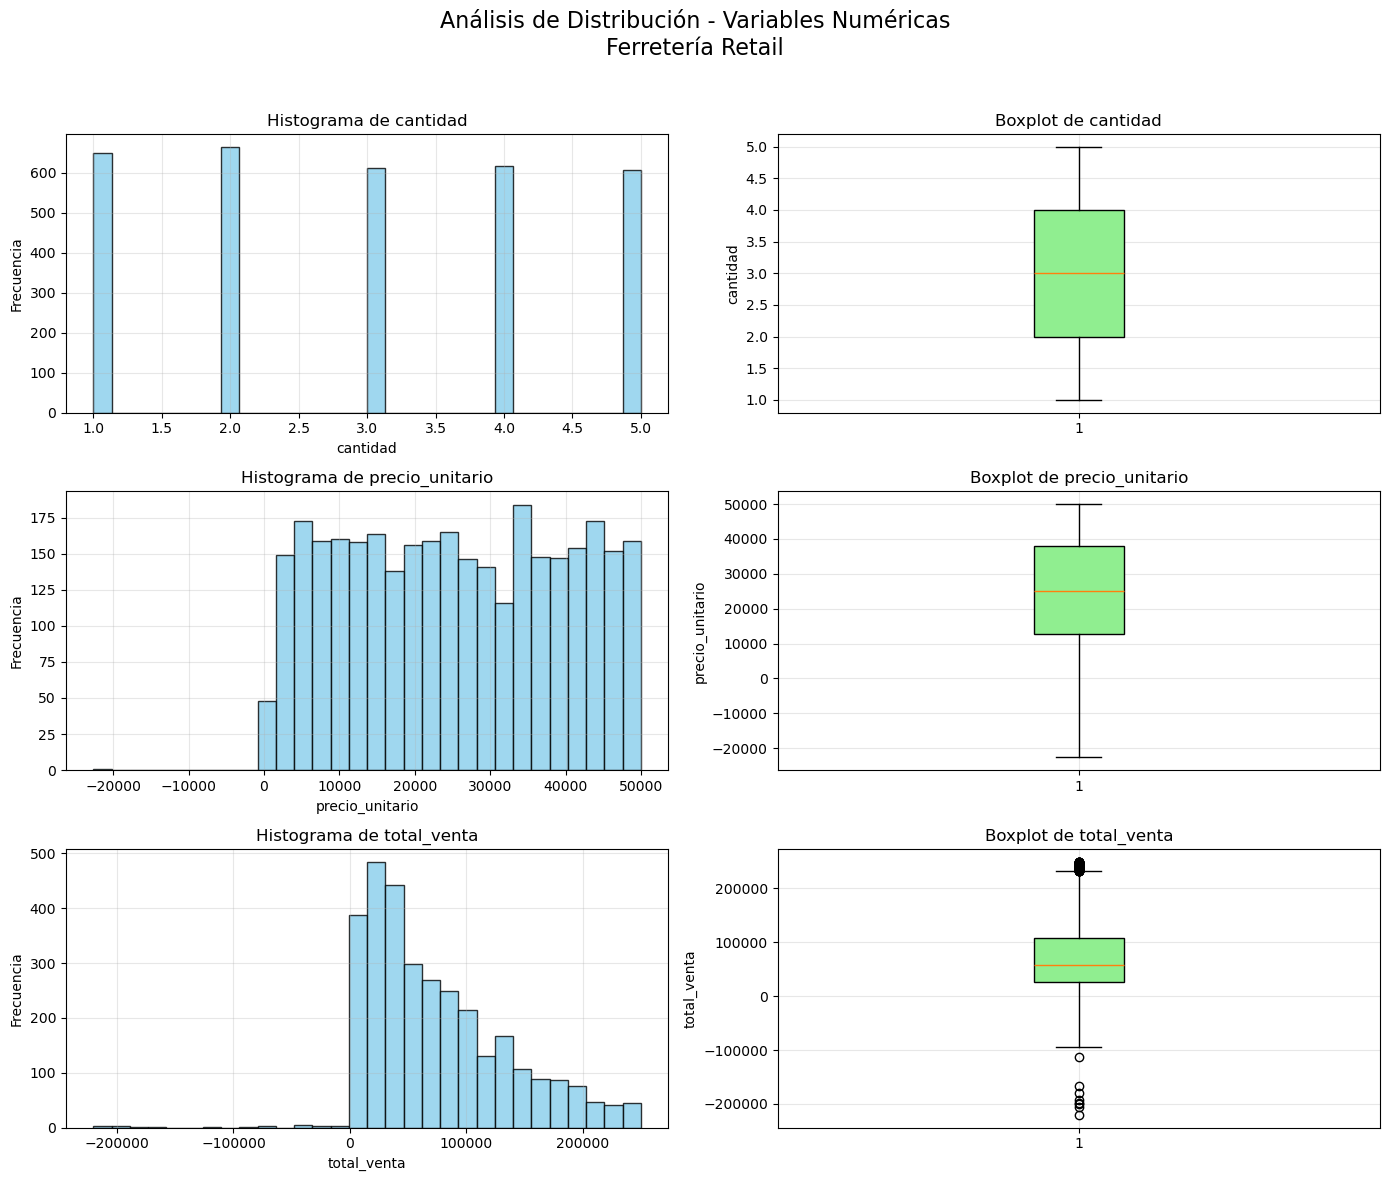

In [3]:

# carga de nombres de las columnas a graficasr a una lista
variables = ['cantidad', 'precio_unitario', 'total_venta']

# Crear figura con subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
fig.suptitle('Análisis de Distribución - Variables Numéricas\nFerretería Retail', fontsize=16)

for i, var in enumerate(variables):
    # Histograma (izquierda)
    axes[i, 0].hist(df[var], bins=30, color='skyblue', edgecolor='black', alpha=0.8)
    axes[i, 0].set_title(f'Histograma de {var}')
    axes[i, 0].set_xlabel(var)
    axes[i, 0].set_ylabel('Frecuencia')
    axes[i, 0].grid(True, alpha=0.3)
    
    # Boxplot (derecha)
    axes[i, 1].boxplot(df[var], patch_artist=True, 
                      boxprops=dict(facecolor='lightgreen'))
    axes[i, 1].set_title(f'Boxplot de {var}')
    axes[i, 1].set_ylabel(var)
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

##### - Crea gráficos de líneas para mostrar las tendencias de ventas a lo largo del tiempo.


Datos globales :
Ventas diarias: 366 registros
Ventas mensuales: 13 registros


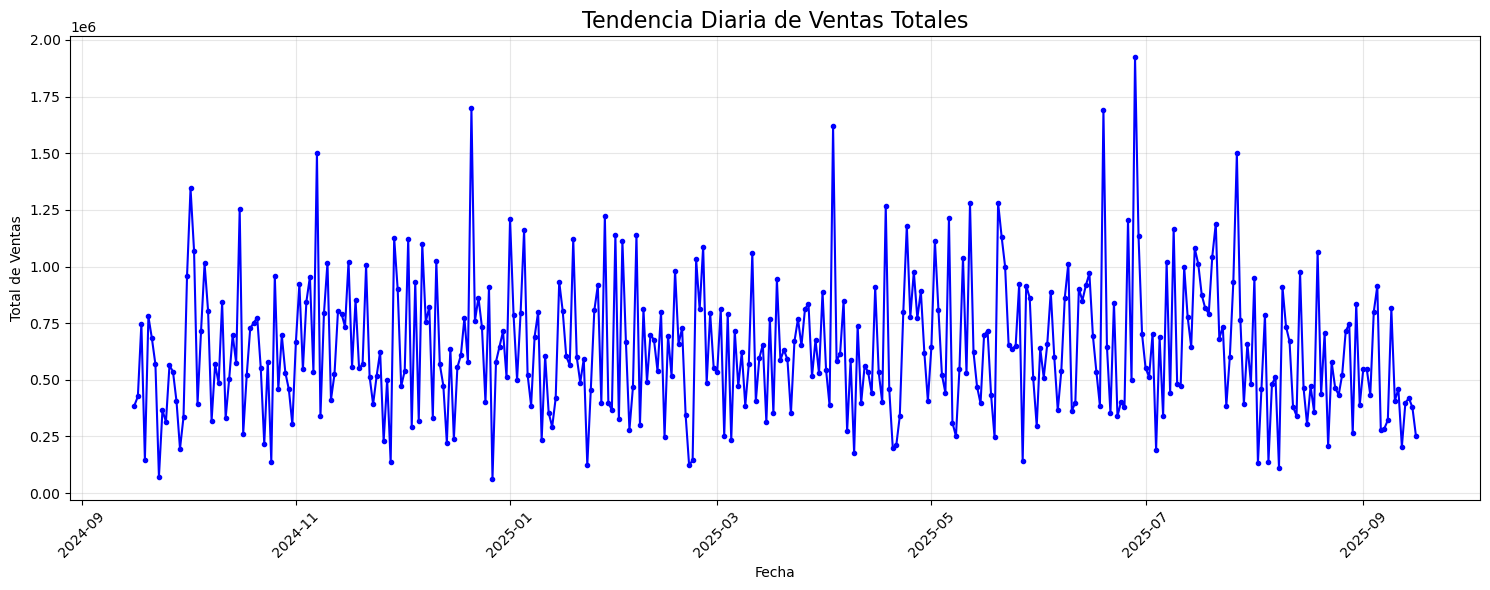

In [4]:
# transformar la columna de fecha a formato datetime
df['fecha_hora'] = pd.to_datetime(df['fecha_hora'])

# columnas de fechas para el grafico
df['fecha'] = df['fecha_hora'].dt.date           # Fecha
df['mes'] = df['fecha_hora'].dt.to_period('M')   # Mes


# Agrupar por día y mes
ventas_diarias = df.groupby('fecha')['total_venta'].sum().reset_index()
ventas_mensuales = df.groupby('mes')['total_venta'].sum().reset_index()

# Convertir 'mes' a datetime para graficar
ventas_mensuales['mes'] = ventas_mensuales['mes'].dt.to_timestamp()

print("Datos globales :")
print(f"Ventas diarias: {len(ventas_diarias)} registros")
print(f"Ventas mensuales: {len(ventas_mensuales)} registros")

plt.figure(figsize=(15, 6))
plt.plot(ventas_diarias['fecha'], ventas_diarias['total_venta'], 
         color='blue', linewidth=1.5, marker='o', markersize=3)

plt.title('Tendencia Diaria de Ventas Totales', fontsize=16)
plt.xlabel('Fecha')
plt.ylabel('Total de Ventas')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### - Utiliza gráficos de dispersión para analizar la relación entre diferentes variables.


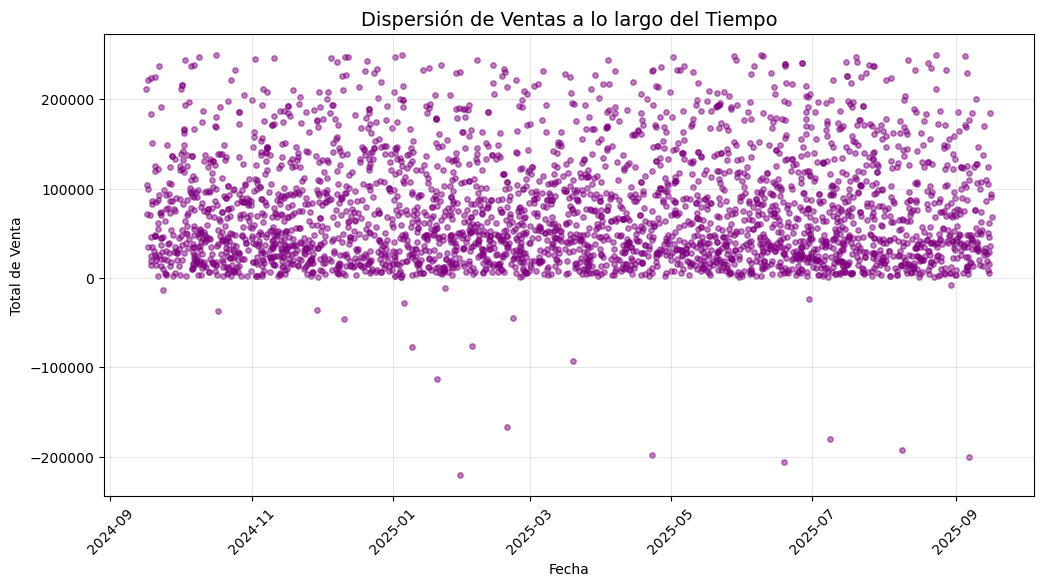

In [5]:
# columnas utilizadas fecha_hora y total_venta

plt.figure(figsize=(12, 6))
plt.scatter(df['fecha_hora'], df['total_venta'], 
            alpha=0.5, s=15, color='purple')

plt.title('Dispersión de Ventas a lo largo del Tiempo', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Total de Venta')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()



##### - Combina histogramas y boxplots para visualizar la distribución de las ventas y detectar valores atípicos.

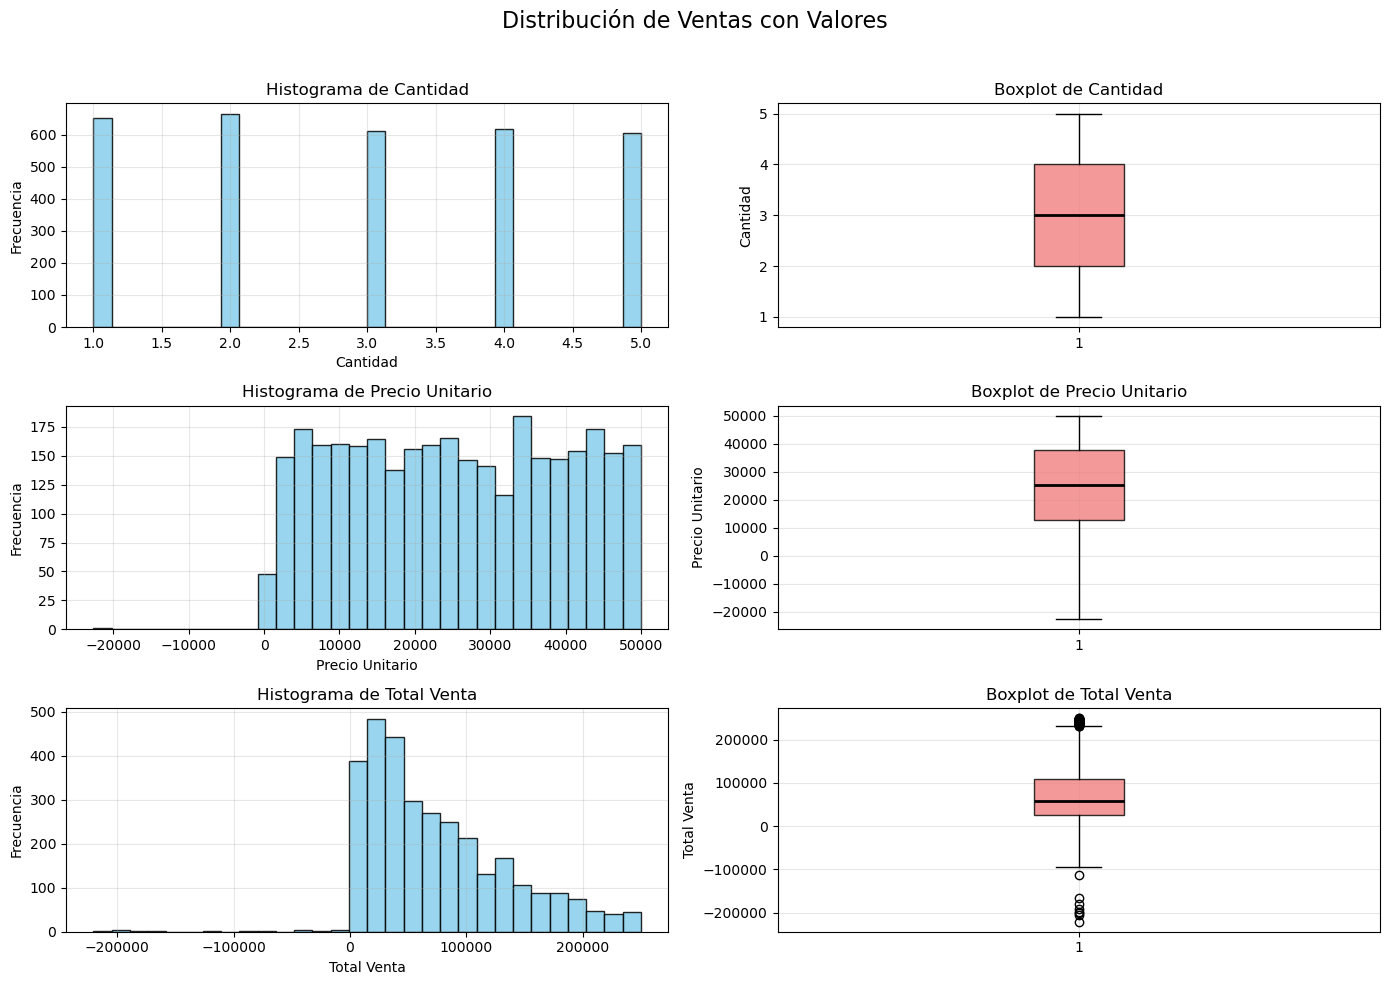

In [6]:
# Variables a analizar
variables = ['cantidad', 'precio_unitario', 'total_venta']

# 2. Crear figura con subplots combinados
fig, axes = plt.subplots(nrows=len(variables), ncols=2, figsize=(14, 10))
fig.suptitle('Distribución de Ventas con Valores', fontsize=16)

for i, var in enumerate(variables):
    # Histograma (izquierda)
    axes[i, 0].hist(df[var], bins=30, color='skyblue', edgecolor='black', alpha=0.85)
    axes[i, 0].set_title(f'Histograma de {var.replace("_", " ").title()}')
    axes[i, 0].set_xlabel(var.replace("_", " ").title())
    axes[i, 0].set_ylabel('Frecuencia')
    axes[i, 0].grid(True, alpha=0.3)
    
    # Boxplot (derecha)
    bp = axes[i, 1].boxplot(df[var], patch_artist=True, 
                           boxprops=dict(facecolor='lightcoral', alpha=0.8),
                           medianprops=dict(color='black', linewidth=2))
    axes[i, 1].set_title(f'Boxplot de {var.replace("_", " ").title()}')
    axes[i, 1].set_ylabel(var.replace("_", " ").title())
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()